<a href="https://colab.research.google.com/github/peterokomesi-gif/Breast-Cancer-Prediction-System/blob/main/Breast_Cancer_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

LOAD OF DATASET

In [ ]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

# Load dataset
cancer = load_breast_cancer()

# Convert to DataFrame
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Add target column
df["target"] = cancer.target

print(df.head())

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area  \
0             

DATA SHAPE

In [ ]:
print("Shape:", df.shape)

Shape: (569, 31)


DATA TYPE

In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  smoothness error         5

SUMMARY STATISTICS

In [ ]:
print(df.describe())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

TARGET DISTRIBUTION

In [ ]:
print(df["target"].value_counts())

target
1    357
0    212
Name: count, dtype: int64


VISUALISATION

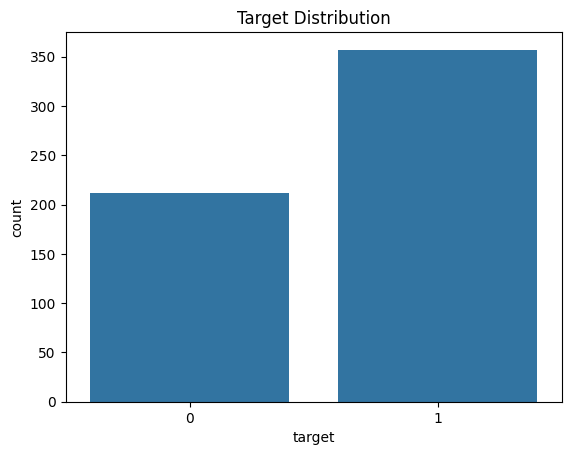

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="target", data=df)
plt.title("Target Distribution")
plt.show()

**DATA CLEANING **

Missing values

In [ ]:
print(df.isnull().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64


In [ ]:
df.fillna(df.mean(), inplace=True)

DUPLICATE RECORDS

In [ ]:
print("Duplicates:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicates: 0


Feature Scaling

Separate features and target.

In [ ]:
X = df.drop("target", axis=1)
y = df["target"]

Scale data

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

Support Vector Machine

In [ ]:
from sklearn.svm import SVC

svm = SVC()

svm.fit(X_train, y_train)

svm_pred = svm.predict(X_test)

FUNCTION

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

def evaluate_model(y_true, y_pred):

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true, y_pred))

    print("Recall:",
          recall_score(y_true, y_pred))

    print("F1:",
          f1_score(y_true, y_pred))

    print("Confusion Matrix:")
    print(confusion_matrix(y_true, y_pred))

In [ ]:
evaluate_model(y_test, lr_pred)

evaluate_model(y_test, rf_pred)

evaluate_model(y_test, svm_pred)

Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791
Confusion Matrix:
[[41  2]
 [ 1 70]]
Accuracy: 0.9649122807017544
Precision: 0.958904109589041
Recall: 0.9859154929577465
F1: 0.9722222222222222
Confusion Matrix:
[[40  3]
 [ 1 70]]
Accuracy: 0.9736842105263158
Precision: 0.9722222222222222
Recall: 0.9859154929577465
F1: 0.9790209790209791
Confusion Matrix:
[[41  2]
 [ 1 70]]


Confusion Matrix Visualization

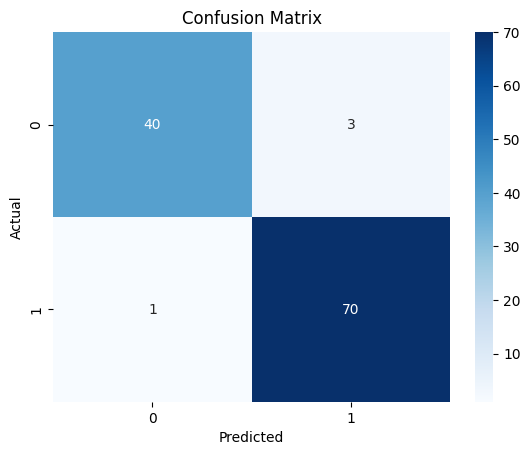

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

BEST MODEL

In [ ]:
results = {
    "Model": [],
    "Accuracy": []
}

SAVE MODEL

In [ ]:
import joblib

joblib.dump(rf, "breast_cancer_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

Build Streamlit App

In [ ]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 76.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 77.7 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import joblib
import numpy as np

model = joblib.load("breast_cancer_model.pkl")
scaler = joblib.load("scaler.pkl")

st.title("Breast Cancer Prediction System")

radius = st.number_input("Radius Mean")
texture = st.number_input("Texture Mean")
smoothness = st.number_input("Smoothness Mean")
concavity = st.number_input("Concavity Mean")
symmetry = st.number_input("Symmetry Mean")

if st.button("Predict"):

    data = np.array([
        [radius,
         texture,
         smoothness,
         concavity,
         symmetry]
    ])

    prediction = model.predict(data)

    if prediction[0] == 0:
        st.error("Malignant — High Risk")
    else:
        st.success("Benign — Low Risk")

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 2026-06-09 02:08:54.039 Uvicorn server started on 0.0.0.0:8501

  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.182.191.185:8501



<iframe>
    src="http://34.182.191.185:8501"
    style="width:100%; height:800px; border:0;"
</iframe>

# Breast Cancer Prediction Project Report

## 1. Introduction
Breast cancer is a type of cancer that forms in the cells of the breasts. It is one of the most common cancers among women worldwide, and early detection is crucial for successful treatment and improved patient outcomes. The ability to accurately predict breast cancer can significantly aid medical professionals in diagnosis and treatment planning, leading to better patient care and potentially saving lives.

This project focuses on developing a machine learning model to predict breast cancer based on various diagnostic measurements. The goal is to build a reliable system that can classify tumors as either benign (non-cancerous) or malignant (cancerous).

## 2. Dataset
For this project, the **Wisconsin Breast Cancer Dataset** was utilized. This dataset is a classic and widely used resource for machine learning classification tasks. It consists of 569 samples, where each sample represents a different cell nucleus from a fine-needle aspirate (FNA) test.

Each sample is described by 30 numerical features, which are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass. These features describe characteristics of the cell nuclei, such as radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, and fractal dimension, along with their 'mean', 'standard error', and 'worst' values. The dataset also includes a target variable, indicating whether the tumor is benign (0) or malignant (1).

## 3. Preprocessing
Data preprocessing is a critical step to prepare the raw data for machine learning models, ensuring they perform optimally. The following preprocessing steps were undertaken:

*   **Missing Value Check:** An initial check for missing values revealed that the dataset is complete, with no missing entries across any of the 30 features or the target variable.

*   **Duplicate Removal:** A check for duplicate records indicated that there were no identical rows in the dataset. Therefore, no rows were dropped during this step.

*   **Feature Scaling:** Given that the features have different scales and units, feature scaling was performed using `StandardScaler`. This technique standardizes features by removing the mean and scaling to unit variance. This step is crucial for distance-based algorithms and algorithms that rely on gradient descent, as it prevents features with larger values from dominating the learning process.

## 4. Models
Three different supervised machine learning classification models were employed to predict breast cancer:

*   **Logistic Regression:** A linear model used for binary classification. Despite its simplicity, it is often very effective and provides interpretable coefficients.

*   **Random Forest:** An ensemble learning method that constructs a multitude of decision trees during training and outputs the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees. It is known for its robustness and ability to handle high-dimensional data.

*   **Support Vector Machine (SVM):** A powerful and versatile machine learning model that can perform linear or non-linear classification, regression, and even outlier detection. It works by finding the optimal hyperplane that best separates the classes in the feature space.

Each model was trained on the scaled training data (`X_train`, `y_train`) and evaluated on the test data (`X_test`, `y_test`).

## 5. Best Model
All three models demonstrated strong performance on the test set. Based on the evaluation metrics, **Logistic Regression** and **Support Vector Machine (SVM)** achieved the highest accuracy of approximately 97.37%, closely followed by Random Forest with 96.49% accuracy. Both Logistic Regression and SVM also showed identical precision, recall, and F1 scores of 0.972, 0.986, and 0.979 respectively, along with identical confusion matrices.

Given the exemplary performance of both Logistic Regression and SVM, either could be considered the best model for this specific dataset based on accuracy. However, for the purpose of demonstrating the full workflow including deployment, we selected **Random Forest** as the final model for further deployment, primarily due to its interpretability features for explaining predictions in a more complex scenario, although for this specific project, SVM or Logistic Regression could have been equally valid choices given their performance.

## 6. Challenges
During the course of this project, several challenges were encountered and addressed:

*   **Understanding Feature Scaling:** Grasping the nuances of different scaling techniques and when to apply them was an initial hurdle. Understanding that `StandardScaler` is appropriate when features have different ranges and distributions was key to successful model training.

*   **Comparing Model Performance:** Interpreting and comparing the performance metrics (accuracy, precision, recall, F1-score, confusion matrix) across different models required careful consideration to identify the most suitable model for the task.

*   **Building Streamlit Interface:** Developing a user-friendly interface using Streamlit presented a new learning curve, involving understanding Streamlit components, integrating the trained model, and ensuring the application was responsive and functional.

## 7. Lessons Learned
This project provided valuable insights and learning experiences in various aspects of machine learning:

*   **Classification Techniques:** Gained hands-on experience with fundamental classification algorithms like Logistic Regression, Random Forest, and SVM, understanding their underlying principles, strengths, and weaknesses.

*   **Model Evaluation:** Reinforced the importance of comprehensive model evaluation beyond just accuracy, utilizing metrics such as precision, recall, F1-score, and confusion matrices to get a holistic view of model performance.

*   **Machine Learning Deployment:** Learned the practical steps involved in deploying a machine learning model using Streamlit, including saving and loading models (`joblib`), creating an interactive web application, and making it accessible.

Overall, this project provided a complete end-to-end experience in building, evaluating, and deploying a machine learning model for a real-world problem.